# 02 — EDA: bureau + bureau_balance

Análisis exploratorio del historial crediticio en **otras instituciones** (bureau de crédito).  
Todo el análisis se orienta al TARGET de `application_train`.

## Estructura de las tablas
```
application_train (SK_ID_CURR)
    └── bureau.csv          (SK_ID_CURR → muchos créditos)
              └── bureau_balance.csv  (SK_ID_BUREAU → saldo mensual)
```

## Contenido
1. CSV → Parquet (una sola vez)
2. Shape y estructura de bureau + bureau_balance
3. Valores faltantes
4. Créditos por tipo (CREDIT_ACTIVE) y tasa de default
5. Aggregaciones a nivel SK_ID_CURR
6. Correlación de aggregaciones con TARGET
7. KDE por TARGET — top aggregaciones
8. Resumen de candidatas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

COLOR_0 = "#000986"   
COLOR_1 = "#fc1c03" 

ROOT      = os.path.abspath(os.path.join('..', '..'))
DATA_RAW  = os.path.join(ROOT, 'data', 'raw')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

## 1. CSV → Parquet

In [2]:
BURO_PARQ  = os.path.join(DATA_PROC, 'bureau.parquet')
BUROB_PARQ = os.path.join(DATA_PROC, 'bureau_balance.parquet')

if not os.path.exists(BURO_PARQ):
    print('Convirtiendo bureau.csv → parquet ...')
    buro = pd.read_csv(os.path.join(DATA_RAW, 'bureau.csv'))
    buro.to_parquet(BURO_PARQ, index=False)
    print(f'  Guardado: {BURO_PARQ}')
else:
    print('bureau.parquet ya existe.')

if not os.path.exists(BUROB_PARQ):
    print('Convirtiendo bureau_balance.csv → parquet ...')
    burob = pd.read_csv(os.path.join(DATA_RAW, 'bureau_balance.csv'))
    burob.to_parquet(BUROB_PARQ, index=False)
    print(f'  Guardado: {BUROB_PARQ}')
else:
    print('bureau_balance.parquet ya existe.')

Convirtiendo bureau.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\bureau.parquet
Convirtiendo bureau_balance.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\bureau_balance.parquet


## 2. Carga y estructura

In [3]:
buro  = pd.read_parquet(BURO_PARQ)
burob = pd.read_parquet(BUROB_PARQ)
train = pd.read_parquet(os.path.join(DATA_PROC, 'app_train.parquet'))[['SK_ID_CURR', 'TARGET']]

print(f'bureau        : {buro.shape[0]:>10,} filas × {buro.shape[1]} columnas')
print(f'bureau_balance: {burob.shape[0]:>10,} filas × {burob.shape[1]} columnas')
print(f'\nClientes únicos en bureau: {buro["SK_ID_CURR"].nunique():,}')
print(f'Clientes únicos en train : {train["SK_ID_CURR"].nunique():,}')
print(f'Créditos únicos bureau   : {buro["SK_ID_BUREAU"].nunique():,}')
print(f'Créditos en bureau_balance: {burob["SK_ID_BUREAU"].nunique():,}')

print('\nburo — primeras filas:')
display(buro.head(3))
print('burob — primeras filas:')
display(burob.head(3))

bureau        :  1,716,428 filas × 17 columnas
bureau_balance: 27,299,925 filas × 3 columnas

Clientes únicos en bureau: 305,811
Clientes únicos en train : 307,511
Créditos únicos bureau   : 1,716,428
Créditos en bureau_balance: 817,395

buro — primeras filas:


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN


burob — primeras filas:


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C


## 3. Valores faltantes

In [4]:
miss_buro = buro.isnull().mean().mul(100).round(2).sort_values(ascending=False)
miss_buro = miss_buro[miss_buro > 0]
print('bureau — columnas con NA:')
display(miss_buro.to_frame('% NA'))

miss_burob = burob.isnull().mean().mul(100).round(2)
miss_burob = miss_burob[miss_burob > 0]
if len(miss_burob) == 0:
    print('\nbureau_balance: sin valores faltantes')
else:
    print('\nbureau_balance — columnas con NA:')
    display(miss_burob.to_frame('% NA'))

bureau — columnas con NA:


,% NA
AMT_ANNUITY,71.47
AMT_CREDIT_MAX_OVERDUE,65.51
DAYS_ENDDATE_FACT,36.92
AMT_CREDIT_SUM_LIMIT,34.48
AMT_CREDIT_SUM_DEBT,15.01
DAYS_CREDIT_ENDDATE,6.15



bureau_balance: sin valores faltantes


## 4. CREDIT_ACTIVE y tasa de default

Analizamos cuántos créditos activos / cerrados tiene cada cliente, y si eso se correlaciona con el default.

In [5]:
# Distribución de CREDIT_ACTIVE
print('CREDIT_ACTIVE — distribución:')
print(buro['CREDIT_ACTIVE'].value_counts())

# Contar créditos activos por cliente y mergear con TARGET
active_count = buro[buro['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').size().rename('N_ACTIVE')
closed_count = buro[buro['CREDIT_ACTIVE'] == 'Closed'].groupby('SK_ID_CURR').size().rename('N_CLOSED')
total_count  = buro.groupby('SK_ID_CURR').size().rename('N_TOTAL')

buro_client = pd.concat([active_count, closed_count, total_count], axis=1).fillna(0)
buro_client = buro_client.merge(train, on='SK_ID_CURR', how='inner')

print(f'\nCorrelaciones con TARGET:')
for col in ['N_ACTIVE', 'N_CLOSED', 'N_TOTAL']:
    corr_val = buro_client[col].corr(buro_client['TARGET'])
    print(f'  {col}: {corr_val:.4f}')

CREDIT_ACTIVE — distribución:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

Correlaciones con TARGET:
  N_ACTIVE: 0.0671
  N_CLOSED: -0.0308
  N_TOTAL: 0.0041


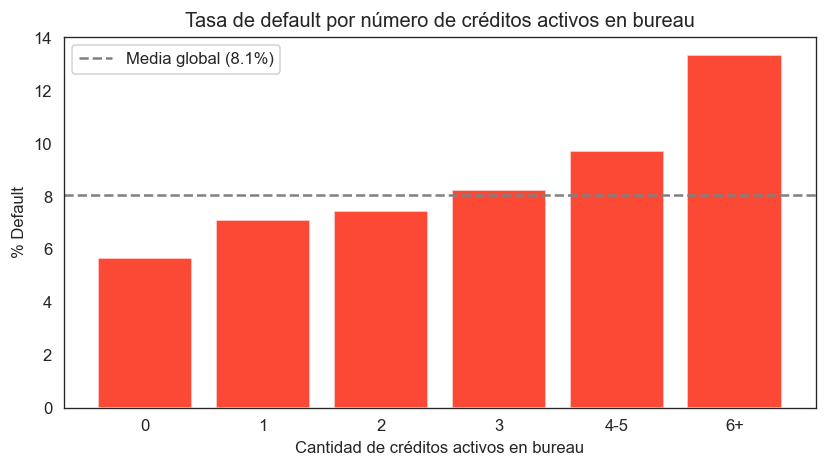

In [6]:
# % Default según número de créditos activos (bins)
global_rate = train['TARGET'].mean()

buro_client['N_ACTIVE_BIN'] = pd.cut(buro_client['N_ACTIVE'], 
                                      bins=[-0.1, 0, 1, 2, 3, 5, 100],
                                      labels=['0', '1', '2', '3', '4-5', '6+'])
active_stats = buro_client.groupby('N_ACTIVE_BIN', observed=True)['TARGET'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(active_stats)), active_stats['mean'] * 100,
       color=COLOR_1, alpha=0.8, edgecolor='white')
ax.axhline(global_rate * 100, color='gray', linestyle='--',
           label=f'Media global ({global_rate*100:.1f}%)')
ax.set_xticks(range(len(active_stats)))
ax.set_xticklabels(active_stats.index)
ax.set_xlabel('Cantidad de créditos activos en bureau')
ax.set_ylabel('% Default')
ax.set_title('Tasa de default por número de créditos activos en bureau')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Aggregaciones de bureau a nivel SK_ID_CURR

Construimos features aggregadas para el cliente y analizamos su relación con el TARGET.

In [7]:
# Aggregaciones numéricas clave
num_agg = {
    'DAYS_CREDIT':             ['mean', 'min', 'max'],
    'CREDIT_DAY_OVERDUE':      ['max', 'mean'],
    'DAYS_CREDIT_ENDDATE':     ['max'],
    'AMT_CREDIT_MAX_OVERDUE':  ['mean'],
    'AMT_CREDIT_SUM':          ['sum', 'mean'],
    'AMT_CREDIT_SUM_DEBT':     ['sum', 'mean'],
    'AMT_CREDIT_SUM_OVERDUE':  ['sum'],
    'DAYS_CREDIT_UPDATE':      ['mean'],
    'CNT_CREDIT_PROLONG':      ['sum'],
    'SK_ID_CURR':              ['count'],   # número total de créditos
}

buro_agg = buro.groupby('SK_ID_CURR').agg(num_agg)
buro_agg.columns = ['BURO_' + '_'.join(col).upper() for col in buro_agg.columns]
buro_agg = buro_agg.rename(columns={'BURO_SK_ID_CURR_COUNT': 'BURO_N_CREDITS'})
buro_agg = buro_agg.reset_index()

# Ratio deuda / crédito
buro_agg['BURO_DEBT_CREDIT_RATIO'] = (
    buro_agg['BURO_AMT_CREDIT_SUM_DEBT_SUM'] / buro_agg['BURO_AMT_CREDIT_SUM_SUM'].replace(0, np.nan)
)

# Agregaciones por status activo
active_agg = buro[buro['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['sum', 'count'],
    'DAYS_CREDIT':    ['mean'],
})
active_agg.columns = ['BURO_ACTIVE_' + '_'.join(col).upper() for col in active_agg.columns]
active_agg = active_agg.rename(columns={'BURO_ACTIVE_AMT_CREDIT_SUM_COUNT': 'BURO_CREDIT_ACTIVE_COUNT'})
active_agg = active_agg.reset_index()

buro_agg = buro_agg.merge(active_agg, on='SK_ID_CURR', how='left')

print(f'Features de bureau generadas: {buro_agg.shape[1] - 1}')
display(buro_agg.head(3))

Features de bureau generadas: 19


,SK_ID_CURR,BURO_DAYS_CREDIT_MEAN,BURO_DAYS_CREDIT_MIN,BURO_DAYS_CREDIT_MAX,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,BURO_DAYS_CREDIT_ENDDATE_MAX,BURO_AMT_CREDIT_MAX_OVERDUE_MEAN,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_MEAN,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_AMT_CREDIT_SUM_DEBT_MEAN,BURO_AMT_CREDIT_SUM_OVERDUE_SUM,BURO_DAYS_CREDIT_UPDATE_MEAN,BURO_CNT_CREDIT_PROLONG_SUM,BURO_N_CREDITS,BURO_DEBT_CREDIT_RATIO,BURO_ACTIVE_AMT_CREDIT_SUM_SUM,BURO_CREDIT_ACTIVE_COUNT,BURO_ACTIVE_DAYS_CREDIT_MEAN
0,100001,-735.00,-1572,-49,0,0.0,1778.0,NaN,1453365.000,207623.571429,596686.5,85240.928571,0.0,-93.142857,0,7,0.410555,884025.000,3.0,-309.333333
1,100002,-874.00,-1437,-103,0,0.0,780.0,1681.029,865055.565,108131.945625,245781.0,49156.200000,0.0,-499.875000,0,8,0.284122,481988.565,2.0,-572.500000
2,100003,-1400.75,-2586,-606,0,0.0,1216.0,0.000,1017400.500,254350.125000,0.0,0.000000,0.0,-816.000000,0,4,0.000000,810000.000,1.0,-606.000000


## 6. Correlación de aggregaciones bureau con TARGET

Top 15 features de bureau más correlacionadas con TARGET:


,feature,corr
0,BURO_DAYS_CREDIT_MEAN,0.089729
1,BURO_DAYS_CREDIT_MIN,0.075248
2,BURO_DAYS_CREDIT_UPDATE_MEAN,0.068927
3,BURO_ACTIVE_DAYS_CREDIT_MEAN,0.064040
4,BURO_CREDIT_ACTIVE_COUNT,0.060930
5,BURO_DEBT_CREDIT_RATIO,0.060235
6,BURO_DAYS_CREDIT_MAX,0.049782
7,BURO_DAYS_CREDIT_ENDDATE_MAX,0.036590
8,BURO_AMT_CREDIT_SUM_MEAN,-0.019957
9,BURO_AMT_CREDIT_SUM_SUM,-0.014057


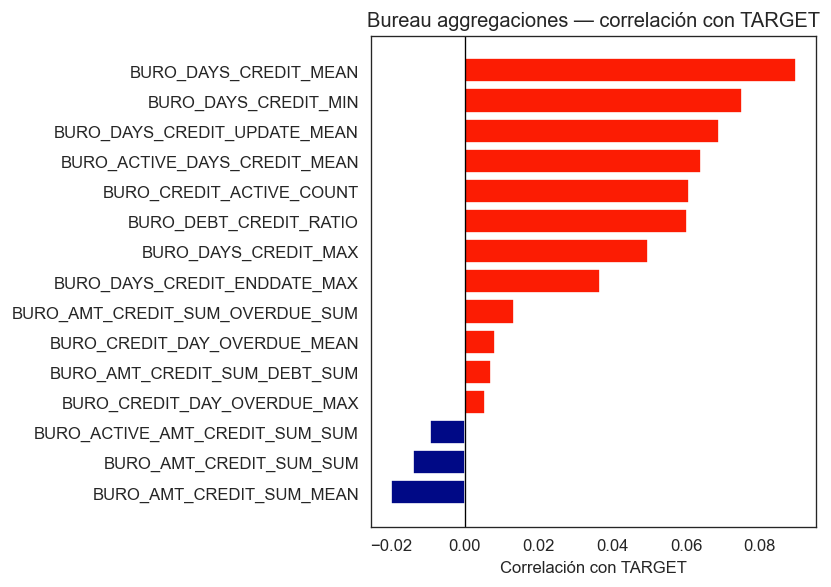

In [8]:
buro_target = buro_agg.merge(train, on='SK_ID_CURR', how='inner')

feat_cols = [c for c in buro_agg.columns if c != 'SK_ID_CURR']
corr_buro = buro_target[feat_cols + ['TARGET']].corrwith(buro_target['TARGET'])
corr_buro = corr_buro.drop('TARGET').sort_values(key=abs, ascending=False)

corr_df = pd.DataFrame({'feature': corr_buro.index, 'corr': corr_buro.values})
corr_df['abs_corr'] = corr_df['corr'].abs()

print('Top 15 features de bureau más correlacionadas con TARGET:')
display(corr_df.head(15)[['feature', 'corr']].reset_index(drop=True))

# Gráfico: top15 por abs, luego ordenar por valor raw para gradiente azul→rojo
top15 = corr_df.head(15).sort_values('corr', ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
colors = [COLOR_0 if c < 0 else COLOR_1 for c in top15['corr']]
ax.barh(top15['feature'], top15['corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con TARGET')
ax.set_title('Bureau aggregaciones — correlación con TARGET')
plt.tight_layout()
plt.show()

## 7. KDE por TARGET — top features bureau

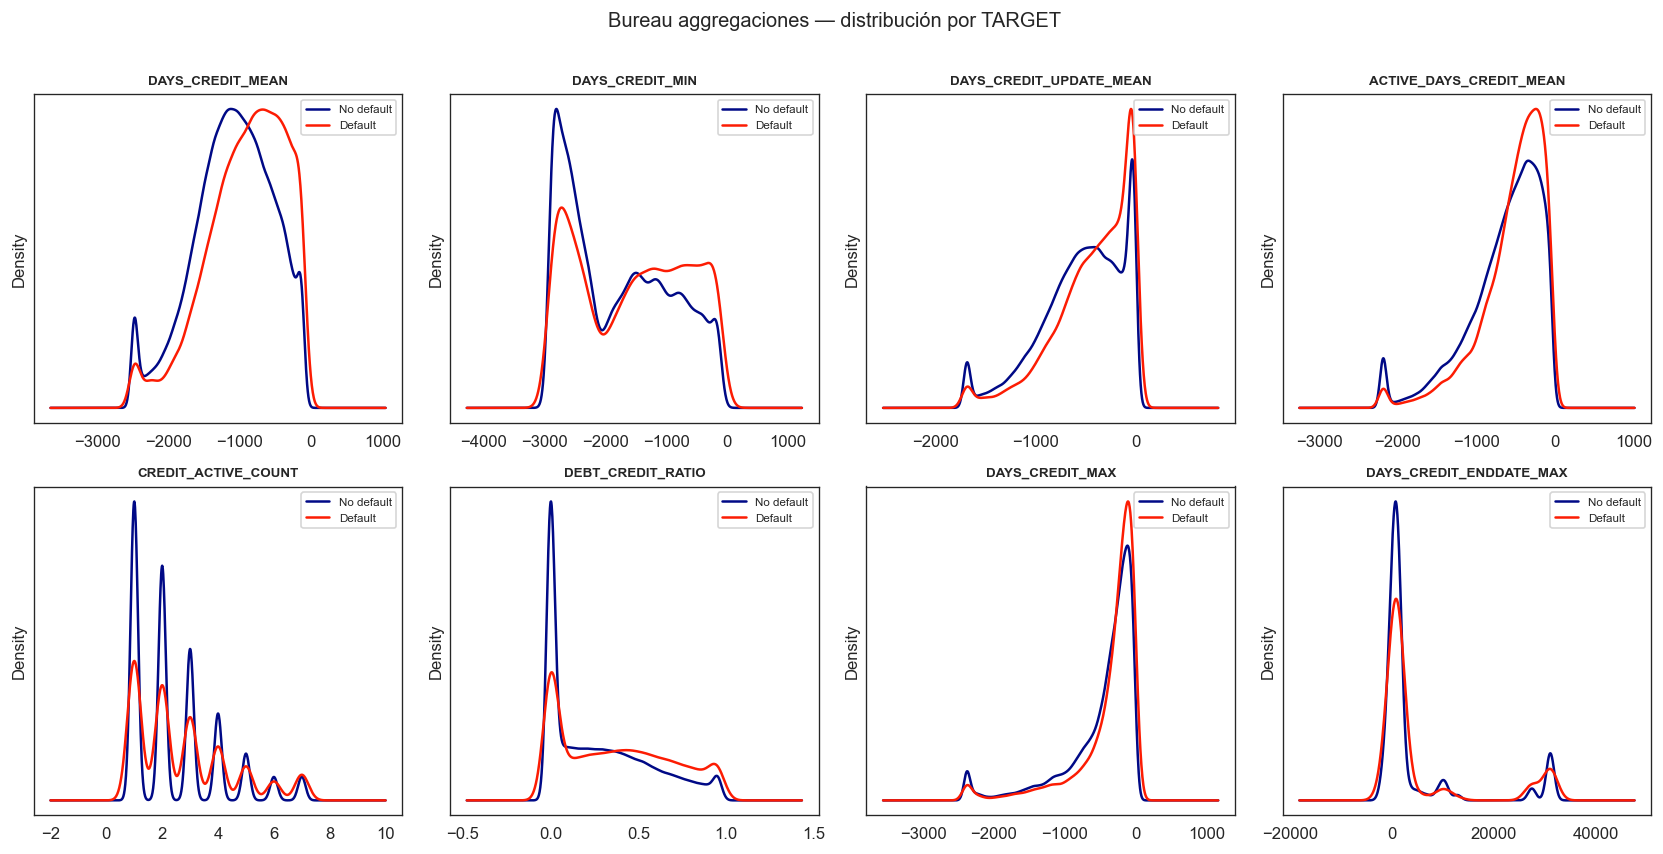

In [9]:
top_buro_feats = corr_df.head(8)['feature'].tolist()

df0 = buro_target[buro_target['TARGET'] == 0]
df1 = buro_target[buro_target['TARGET'] == 1]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_buro_feats):
    ax = axes[i]
    lo = buro_target[col].quantile(0.02)
    hi = buro_target[col].quantile(0.98)
    s0 = df0[col].clip(lo, hi).dropna()
    s1 = df1[col].clip(lo, hi).dropna()
    if len(s0) > 10 and len(s1) > 10:
        s0.plot.kde(ax=ax, color=COLOR_0, label='No default', linewidth=1.5)
        s1.plot.kde(ax=ax, color=COLOR_1, label='Default', linewidth=1.5)
    ax.set_title(col.replace('BURO_', ''), fontsize=8, fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.suptitle('Bureau aggregaciones — distribución por TARGET', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. bureau_balance — análisis de STATUS

In [10]:
# STATUS codes:
# C = cerrado, X = desconocido, 0-5 = meses de mora (5=max)
print('STATUS — distribución:')
print(burob['STATUS'].value_counts())

# Proporción de STATUS de mora (1-5) por crédito → indicador de historial de pago
burob['DPD_FLAG'] = burob['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

# Aggregar bureau_balance por SK_ID_BUREAU
burob_agg = burob.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT=('MONTHS_BALANCE', 'size'),
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),
    BB_DPD_MEAN=('DPD_FLAG', 'mean'),
    BB_DPD_MAX=('DPD_FLAG', 'max'),
).reset_index()

# Unir con bureau para llegar a SK_ID_CURR
buro_with_bb = buro[['SK_ID_BUREAU', 'SK_ID_CURR']].merge(burob_agg, on='SK_ID_BUREAU', how='left')

# Aggregar a nivel SK_ID_CURR
buro_bb_client = buro_with_bb.groupby('SK_ID_CURR').agg(
    BURO_BB_DPD_MEAN=('BB_DPD_MEAN', 'mean'),
    BURO_BB_DPD_MAX=('BB_DPD_MAX', 'max'),
    BURO_BB_MONTHS_SUM=('BB_MONTHS_COUNT', 'sum'),
).reset_index()

# Correlación con TARGET
bb_target = buro_bb_client.merge(train, on='SK_ID_CURR', how='inner')
for col in ['BURO_BB_DPD_MEAN', 'BURO_BB_DPD_MAX', 'BURO_BB_MONTHS_SUM']:
    corr_val = bb_target[col].corr(bb_target['TARGET'])
    print(f'{col}: {corr_val:.4f}')

STATUS — distribución:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64
BURO_BB_DPD_MEAN: 0.0597
BURO_BB_DPD_MAX: 0.0473
BURO_BB_MONTHS_SUM: -0.0136


## 9. Resumen — candidatas de bureau para feature engineering

In [11]:
print('Features seleccionadas de bureau para notebook 05:')
selected = [
    ('BURO_DAYS_CREDIT_MEAN',       'Antigüedad media de créditos externos'),
    ('BURO_CREDIT_ACTIVE_COUNT',    'Cantidad de créditos activos'),
    ('BURO_CREDIT_DAY_OVERDUE_MAX', 'Máximo días en mora en bureau'),
    ('BURO_AMT_CREDIT_SUM_DEBT_SUM','Deuda total en otras instituciones'),
    ('BURO_DEBT_CREDIT_RATIO',      'Ratio deuda/crédito en bureau'),
    ('BURO_BB_DPD_MEAN',            'Proporción mensual de meses con mora (bureau_balance)'),
]
for feat, desc in selected:
    corr_match = corr_buro.get(feat, None)
    if corr_match is not None:
        print(f'  {feat:<35s} corr={corr_match:+.4f}  ← {desc}')
    else:
        print(f'  {feat:<35s}  ← {desc}')

Features seleccionadas de bureau para notebook 05:
  BURO_DAYS_CREDIT_MEAN               corr=+0.0897  ← Antigüedad media de créditos externos
  BURO_CREDIT_ACTIVE_COUNT            corr=+0.0609  ← Cantidad de créditos activos
  BURO_CREDIT_DAY_OVERDUE_MAX         corr=+0.0055  ← Máximo días en mora en bureau
  BURO_AMT_CREDIT_SUM_DEBT_SUM        corr=+0.0071  ← Deuda total en otras instituciones
  BURO_DEBT_CREDIT_RATIO              corr=+0.0602  ← Ratio deuda/crédito en bureau
  BURO_BB_DPD_MEAN                     ← Proporción mensual de meses con mora (bureau_balance)


---
**Próximo notebook**: `03_eda_previous_applications.ipynb` — solicitudes previas en Home Credit.